In [21]:
import sys  # access to system internals
import os  # filesystem utilities
sys.path.append(os.path.abspath(".."))  # allow importing project modules from parent
from scripts.plot_utils import save_all_figs  # auto-save figures on kernel exit
import pandas as pd  # data handling
import seaborn as sns  # plotting helper
import matplotlib.pyplot as plt  # matplotlib interface
import numpy as np  # numerical arrays
import math  # math utilities for layout
sns.set_theme(style="whitegrid", context="talk", palette="crest")  # global plot theme

In [22]:
mat = pd.read_csv("../data/raw/student-mat.csv", sep=";")  # load raw math data
por = pd.read_csv("../data/raw/student-por.csv", sep=";")  # load raw Portuguese data

In [23]:
num_cols_mat = mat.select_dtypes(include=["int64", "float64"]).columns  # numeric columns in math data
num_cols_por = por.select_dtypes(include=["int64", "float64"]).columns  # numeric columns in Portuguese data

In [24]:
def plot_distributions(df, title):  # plot grid of distributions with KDE
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns  # numeric columns
    n = len(numeric_cols)  # number of plots
    cols_per_row = 4  # grid width
    rows = math.ceil(n / cols_per_row)  # rows needed
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3.5))  # subplot grid
    axes = axes.flatten()  # flatten axes array
    palette = sns.color_palette("crest", n)  # color palette
    for i, col in enumerate(numeric_cols):  # iterate columns
        sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color=palette[i])  # hist + KDE
        axes[i].set_title(col, fontsize=10)  # title per plot
        axes[i].set_xlabel("")  # remove x label text
    for ax in axes[n:]:  # extra axes
        ax.remove()  # drop unused axes
    fig.suptitle(title, fontsize=16, y=1.02)  # overall title
    fig.tight_layout()  # adjust layout
    save_all_figs(title , "Raw")
    plt.show()  # display plots

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


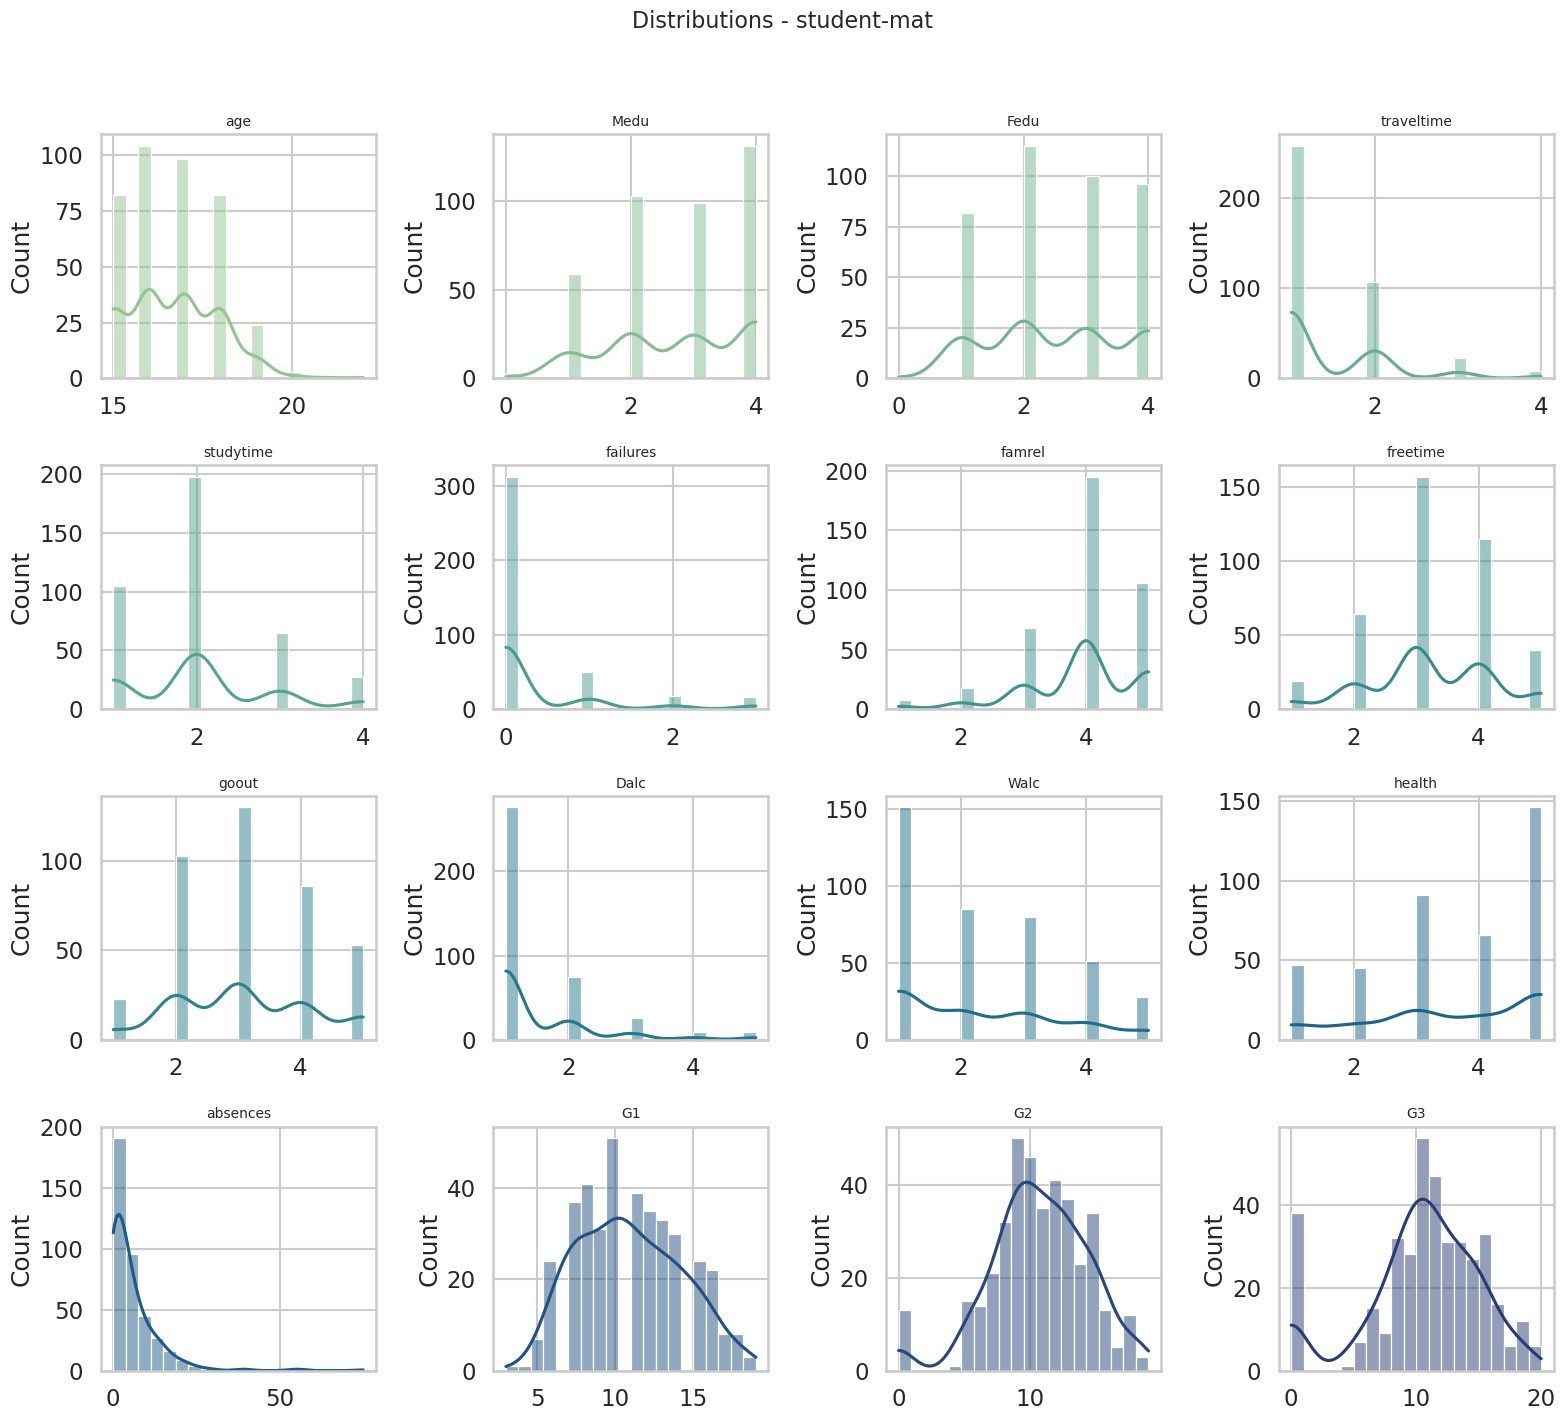

In [25]:
plot_distributions(mat, "Distributions - student-mat")  # distributions for math dataset

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


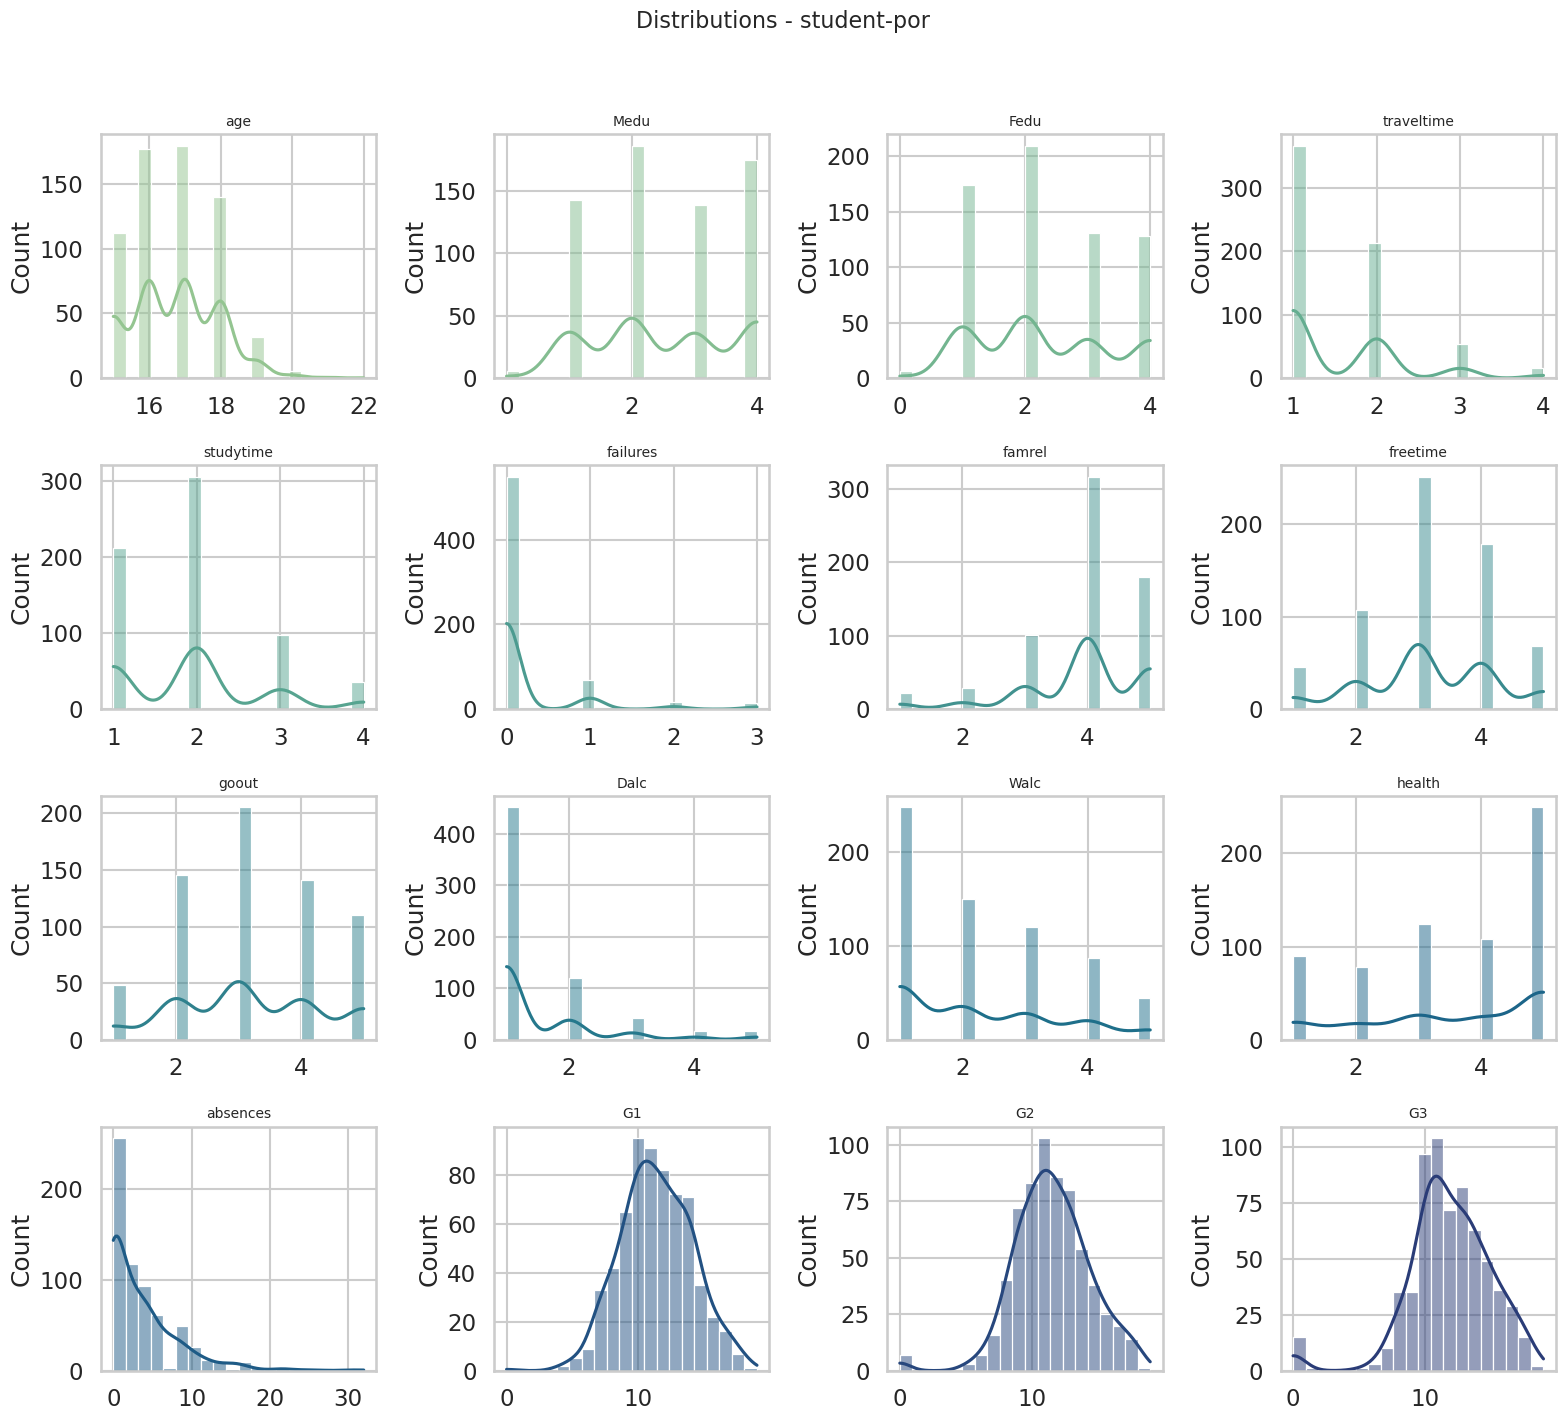

In [26]:
plot_distributions(por, "Distributions - student-por")  # distributions for Portuguese dataset

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


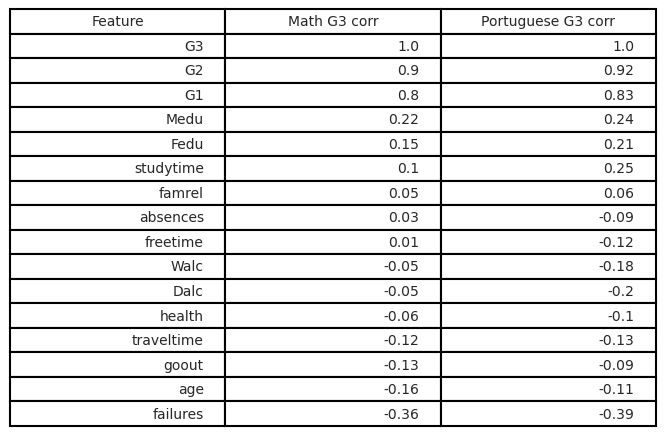

In [27]:
corr_mat = mat[num_cols_mat].corr()['G3'].sort_values(ascending=False)  # correlations vs G3 (math)
corr_por = por[num_cols_por].corr()['G3'].sort_values(ascending=False)  # correlations vs G3 (Portuguese)

corr_table = pd.concat([corr_mat, corr_por], axis=1)  # combine series
corr_table.columns = ['Math G3 corr', 'Portuguese G3 corr']  # label columns
corr_table = corr_table.round(2)  # round values

fig, ax = plt.subplots(figsize=(7, 0.2 * len(corr_table) + 1.5))  # table figure
ax.axis('off')  # hide axes
ax.axis('tight')  # tight layout
table = ax.table(
    cellText=corr_table.reset_index().values,  # table data
    colLabels=['Feature', 'Math G3 corr', 'Portuguese G3 corr'],  # headers
    loc='center',  # center table
)
table.auto_set_font_size(False)  # control font size
table.set_fontsize(10)  # set font size
table.scale(1, 1.3)  # scale table
fig.tight_layout()  # adjust layout
save_all_figs("Corr of features with G3 in mat and por file" , "Raw")
plt.show()  # display table

In [28]:
corr_mat_full = mat[num_cols_mat].corr()  # full correlation matrix (math)
corr_por_full = por[num_cols_por].corr()  # full correlation matrix (Portuguese)

In [29]:
def plot_corr_heatmap(corr_df, title):  # plot full correlation heatmap
    n = len(corr_df.columns)  # number of features
    plt.figure(figsize=(0.5 * n + 6, 0.5 * n + 6))  # size based on features
    sns.heatmap(
        corr_df,  # correlation matrix
        annot=True,  # show values
        fmt=".2f",  # format values
        cmap="RdBu_r",  # diverging cmap
        center=0,  # center at zero
        linewidths=0.3,  # grid lines
        square=True,  # square cells
        cbar_kws={"shrink": 0.6},  # colorbar size
    )
    plt.xticks(rotation=45, ha="right")  # rotate x labels
    plt.yticks(rotation=0)  # y labels orientation
    plt.title(title)  # plot title
    save_all_figs(title , "Raw")
    plt.tight_layout()  # layout

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


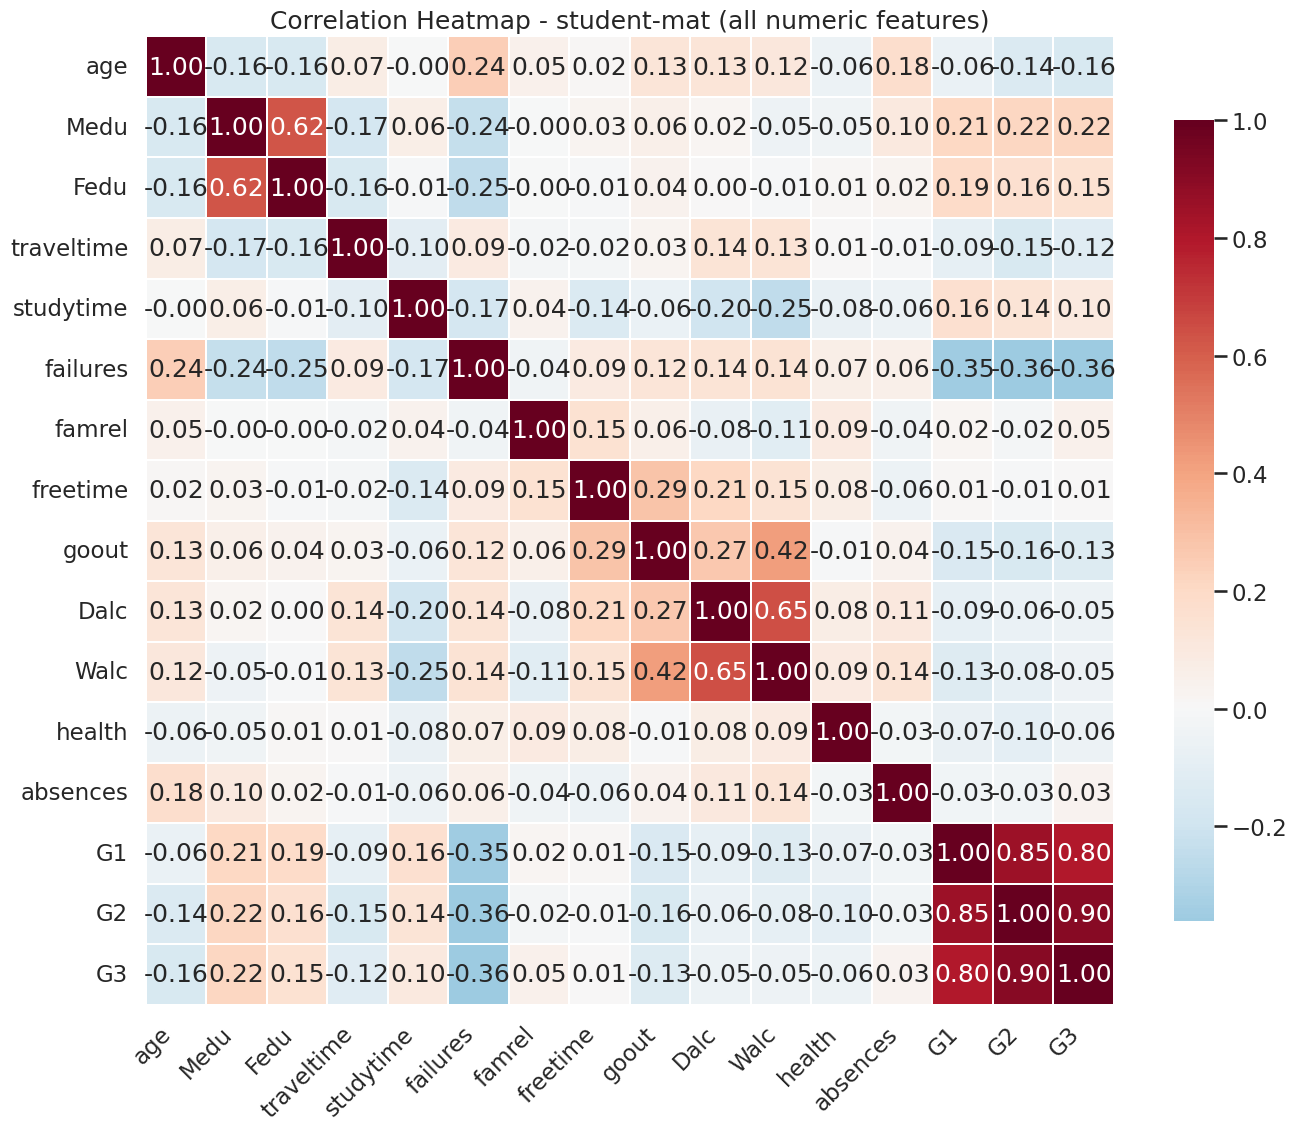

In [30]:
plot_corr_heatmap(corr_mat_full, 'Correlation Heatmap - student-mat (all numeric features)')  # heatmap for math

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


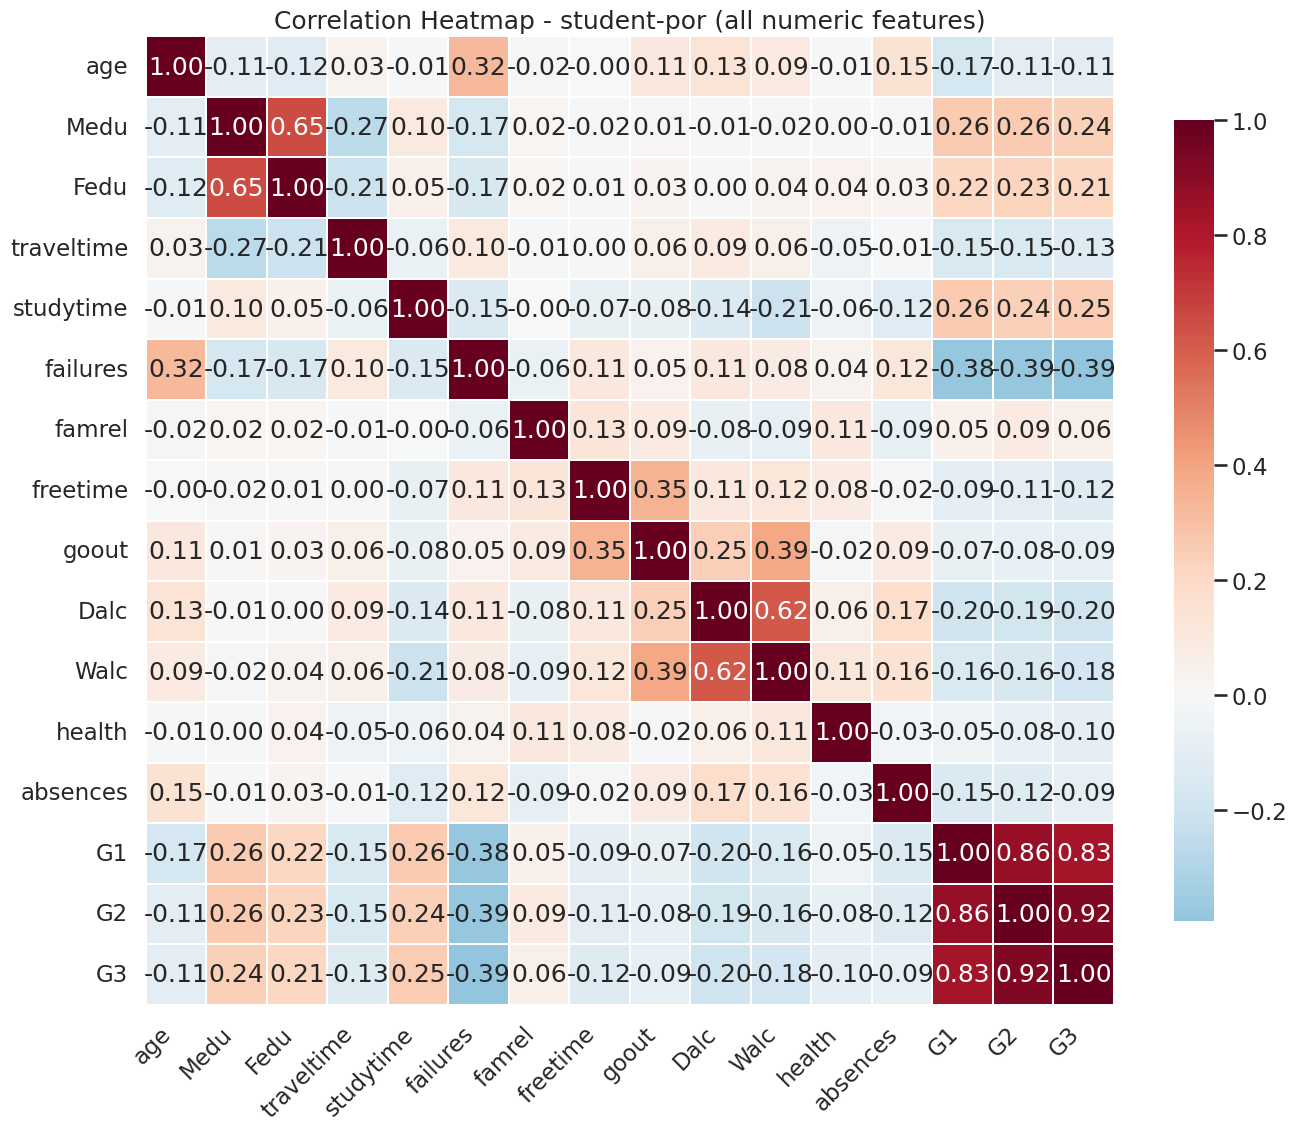

In [31]:
plot_corr_heatmap(corr_por_full, 'Correlation Heatmap - student-por (all numeric features)')  # heatmap for Portuguese

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


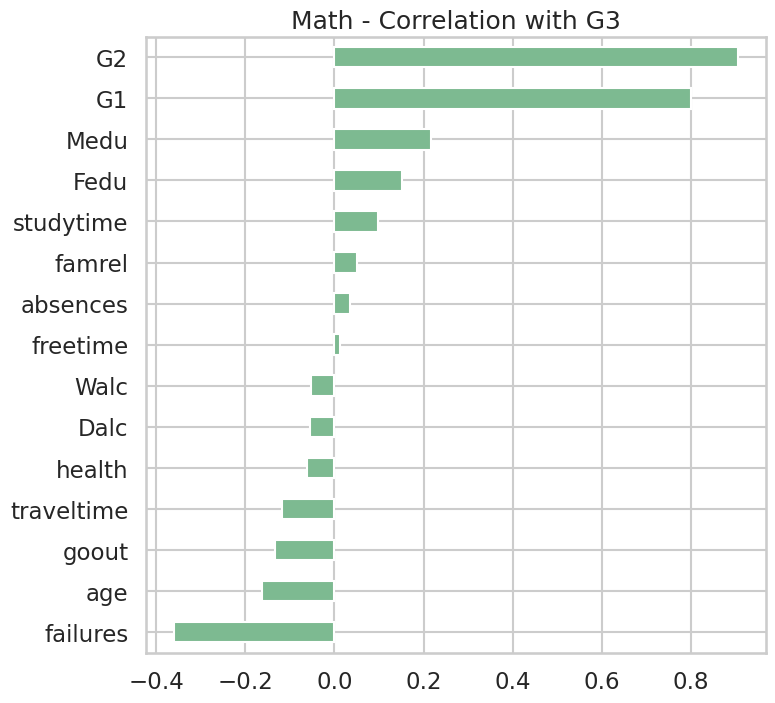

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


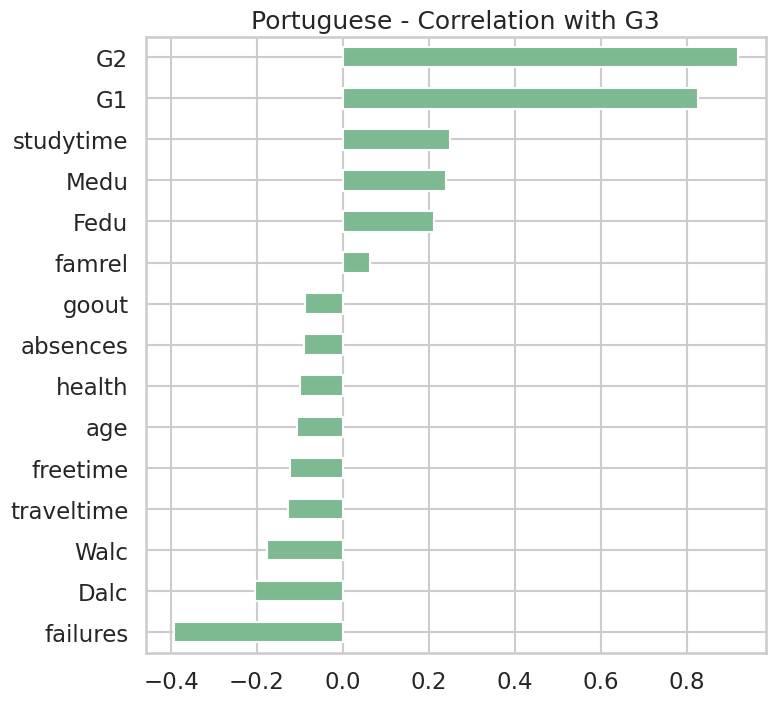

In [32]:
# Correlation with G3
mat_G3_corr = corr_mat_full["G3"].sort_values(ascending=False)  # math correlations sorted
por_G3_corr = corr_por_full["G3"].sort_values(ascending=False)  # Portuguese correlations sorted

plt.figure(figsize=(7,5))  # bar plot figure (math)
mat_G3_corr.drop("G3").sort_values().plot(kind="barh", figsize=(8,8), title="Math - Correlation with G3")  # barh for math
save_all_figs("Math - Correlation with G3" , "Raw")  # save figures
plt.show()  # display

plt.figure(figsize=(7,5))  # bar plot figure (Portuguese)
por_G3_corr.drop("G3").sort_values().plot(kind="barh", figsize=(8,8), title="Portuguese - Correlation with G3")  # barh for Portuguese
save_all_figs("Portuguese - Correlation with G3" , "Raw")  # save figures
plt.show()  # display

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


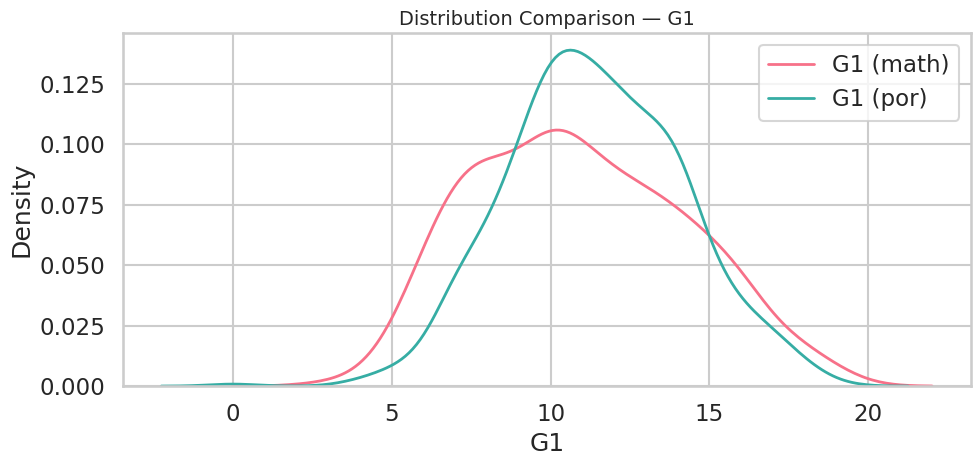

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


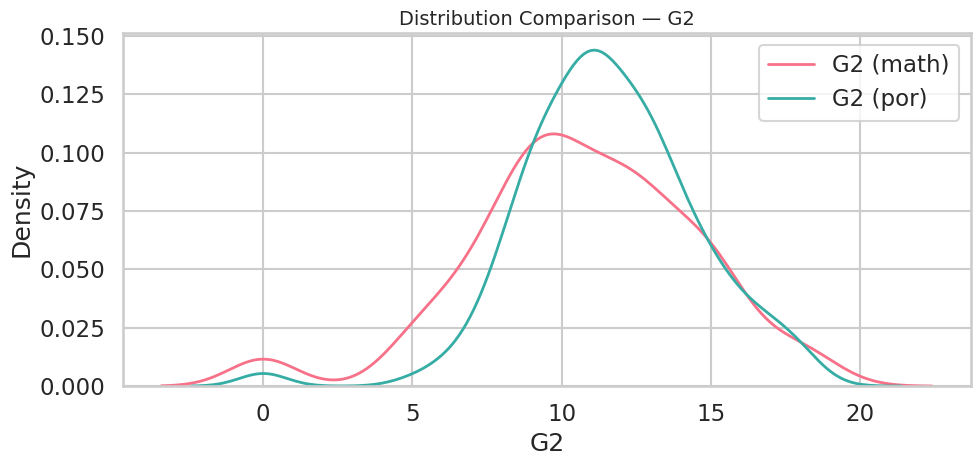

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


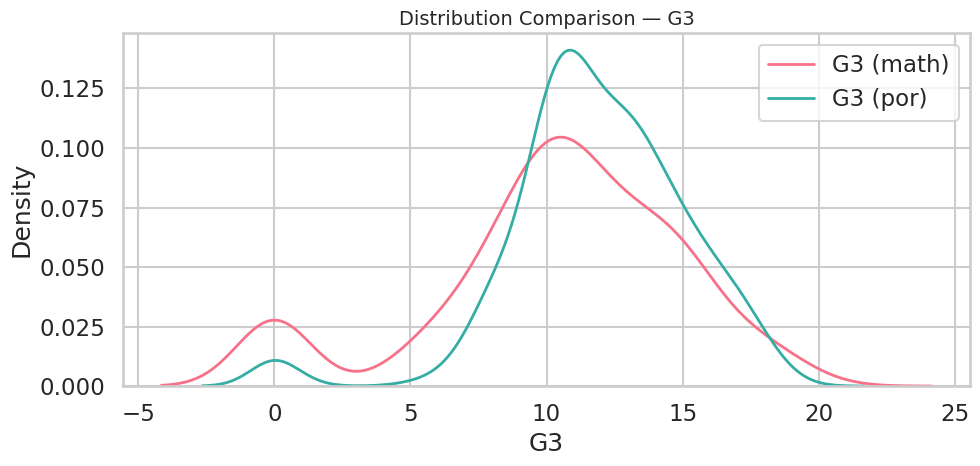

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


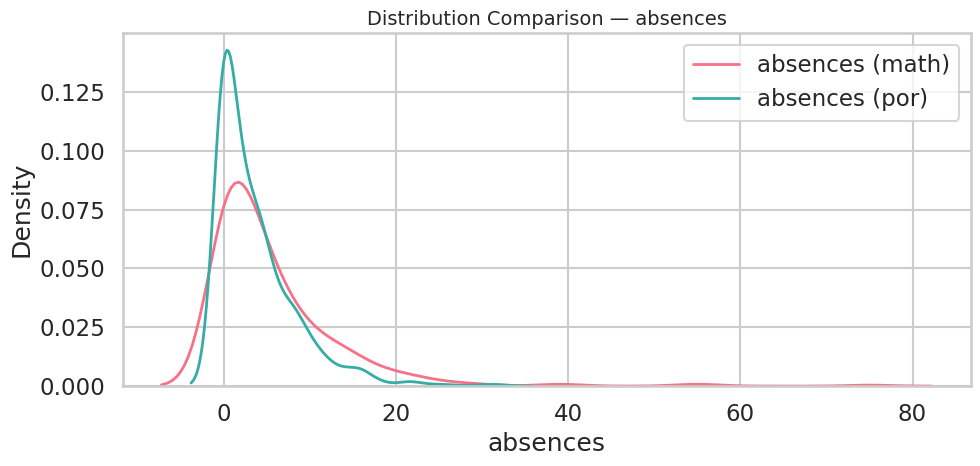

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


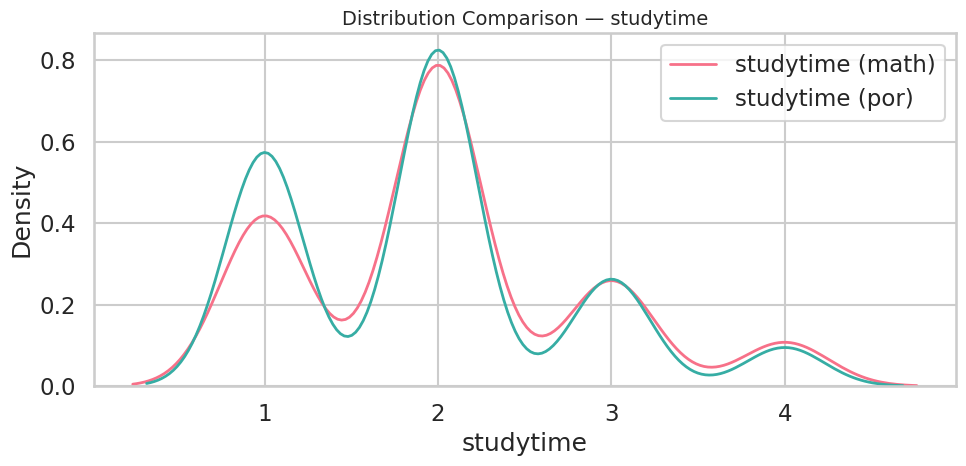

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


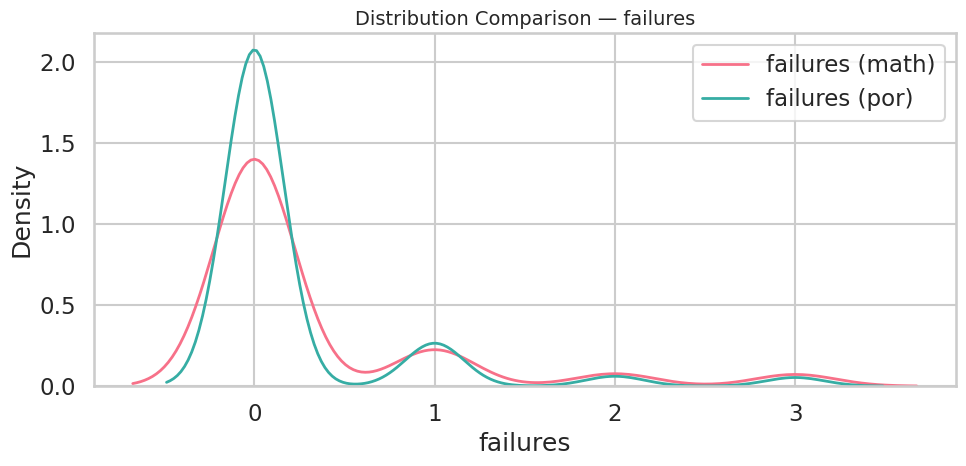

In [33]:
important_cols = ["G1", "G2", "G3", "absences", "studytime", "failures"]  # key features

for col in important_cols:  # iterate features

    plt.figure(figsize=(10, 5))  # figure per feature

    colors = sns.color_palette("husl", 2)  # two-color palette

    sns.kdeplot(
        mat[col], 
        label=f"{col} (math)",
        color=colors[0],
        linewidth=2
    )  # KDE for math

    sns.kdeplot(
        por[col],
        label=f"{col} (por)",
        color=colors[1],
        linewidth=2
    )  # KDE for Portuguese

    plt.title(f"Distribution Comparison — {col}", fontsize=14)  # plot title
    plt.legend()  # legend
    plt.tight_layout()  # layout

    save_all_figs(f"Distribution Comparison — {col}", "Raw")  # save figure
    plt.show()  # display